# 3. Coincidence and significance

This notebook uses only `wdf.analysis`, which works on plain DataFrames and has
no `pytsa` dependency: everything here runs on a machine that never compiled
p4TSA, against trigger tables saved by someone else -- or, as below, made up.

The event tables are synthetic on purpose. What matters is the shape of the
columns, which is what a real per-detector event table from
`wavegram_events` (notebook 2) or `TriggerClusterer` carries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SPAN_S = 3600.0
rng = np.random.default_rng(11)


def detector_events(ifo, n_noise, signal_times, signal_enwdf):
    """One detector's event table: noise events plus a few real ones."""
    times = np.concatenate([rng.uniform(0.0, SPAN_S, n_noise), np.asarray(signal_times)])
    enwdf = np.concatenate([rng.gamma(2.0, 1.8, n_noise) + 4.0, np.asarray(signal_enwdf)])
    freq = np.concatenate([rng.uniform(40, 900, n_noise), np.full(len(signal_times), 180.0)])
    return (pd.DataFrame(dict(cluster_id=np.arange(times.size), ifo=ifo,
                              gpsPeak=times, gpsStart=times - 0.05, duration=0.1,
                              EnWDF=enwdf, freqMean=freq,
                              freqMin=freq * 0.7, freqMax=freq * 1.4))
            .sort_values("gpsPeak").reset_index(drop=True))


SIGNAL_TIMES = np.array([600.0, 1500.0, 2400.0])
H1 = detector_events("H1", 300, SIGNAL_TIMES, [14.0, 9.0, 22.0])
L1 = detector_events("L1", 300, SIGNAL_TIMES + 0.004, [12.0, 8.5, 19.0])

H1.head(3)

,cluster_id,ifo,gpsPeak,gpsStart,duration,EnWDF,freqMean,freqMin,freqMax
0,215,H1,41.288010,41.238010,0.1,7.424153,141.233441,98.863409,197.726817
1,47,H1,60.757974,60.707974,0.1,8.140467,730.996407,511.697485,1023.394970
2,73,H1,64.663328,64.613328,0.1,10.154651,53.195449,37.236815,74.473629


## Coincidence

Two events are coincident if their peak times fall within the light-travel time
between the two sites plus a timing-jitter margin. The margin is not optional:
WDF's peak time is the loudest tile of a window, not a sub-sample arrival-time
measurement, so light-travel time alone would be too tight.

The candidate's statistic is the quadrature sum of the per-detector `EnWDF`.

In [2]:
from wdf.analysis import CoincidenceFinder
from wdf.analysis.detectors import light_travel_time

# The light travel time follows from where the detectors are, so no baseline is
# written into the analysis and any pair of sites can be asked for.
finder = CoincidenceFinder(timing_jitter_s=0.01)
print(f"H1-L1 light travel time  {light_travel_time('H1', 'L1') * 1e3:.1f} ms")
print(f"H1-V1 light travel time  {light_travel_time('H1', 'V1') * 1e3:.1f} ms")
print(f"coincidence reach        {finder.coincidence_window(H1, L1) * 1e3:.1f} ms")

CANDIDATES = finder.find({"H1": H1, "L1": L1})
print(f"\n{len(CANDIDATES)} candidates")
CANDIDATES.nlargest(5, "network_enwdf")[
    ["gps_candidate", "dt_s", "EnWDF_H1", "EnWDF_L1", "network_enwdf"]]

H1-L1 light travel time  10.0 ms
H1-V1 light travel time  27.3 ms
coincidence reach        210.0 ms

11 candidates


,gps_candidate,dt_s,EnWDF_H1,EnWDF_L1,network_enwdf
0,2400.002000,-0.004000,22.000000,19.000000,29.068884
1,600.002000,-0.004000,14.000000,12.000000,18.439089
2,2070.689833,0.045612,5.297135,12.968172,14.008324
3,927.423137,0.004518,8.407613,10.087210,13.131632
4,1500.002000,-0.004000,9.000000,8.500000,12.379418


## Background by time slides

Shifting one detector by an unphysical amount destroys any real coincidence but
leaves each detector's own noise statistics untouched, so re-running the same
coincidence over many shifts measures how often detectors coincide by accident.

The finder and its settings must be the same ones used on the unshifted data:
foreground and background have to be produced by the same procedure and ranked
on the same quantity, or the resulting probability means nothing.

In [3]:
from wdf.analysis import BackgroundEstimator
from wdf.analysis.robust_events import FARConfig

# The rate's denominator is the background livetime, the slides times the span,
# and not the number of candidates the slides happened to produce.
estimator = BackgroundEstimator(finder, FARConfig(n_slides=200, min_shift_s=1.0, seed=3))
BACKGROUND = estimator.background_distribution(
    {"H1": H1, "L1": L1},
    segment_bounds={"H1": (0.0, SPAN_S), "L1": (0.0, SPAN_S)},
)
LIVETIME = float(BACKGROUND.attrs["total_livetime_s"])
print(f"{len(BACKGROUND)} accidental coincidences over "
      f"{LIVETIME / 86400:.1f} days of slide livetime")

1217 accidental coincidences over 8.3 days of slide livetime


In [4]:
RANKED = estimator.rank_candidates(CANDIDATES, BACKGROUND,
                                  segment_duration_s=SPAN_S)
RANKED.nsmallest(5, "fap")[
    ["gps_candidate", "network_enwdf", "n_background_ge", "fap", "far_per_day"]]

,gps_candidate,network_enwdf,n_background_ge,fap,far_per_day
0,2400.002000,29.068884,0,0.004988,0.12
1,600.002000,18.439089,6,0.034395,0.84
2,1500.002000,12.379418,110,0.425928,13.32
3,927.423137,13.131632,124,0.464739,15.00
4,2070.689833,14.008324,818,0.983344,98.28


Three things worth reading off that table.

The loud injection is comfortably above everything the background produced, so
its false-alarm probability is set by the number of slides rather than by any
background event that reached it -- with 200 slides and no background above it,
the "+1" convention gives about 1/201. More slides would push it lower; the
estimate is bounded by how much background was generated.

The weakest injection is *not* significant. It is recovered, it is a real
coincidence, and the background still produces accidents that loud. That is the
honest answer, and it is why efficiency and significance are separate questions.

There is also an accidental coincidence that outranks the weakest injection.
With 300 noise events per detector in an hour and a 30 ms window, that is
expected, not a bug.

## ROC

The ROC curve asks the same question over a range of thresholds: at each
threshold, what fraction of real events survive, and what fraction of background
does. It needs a set of known positives, which only simulated data can give.

3 of 3 injections recovered in coincidence
AUC = 0.891


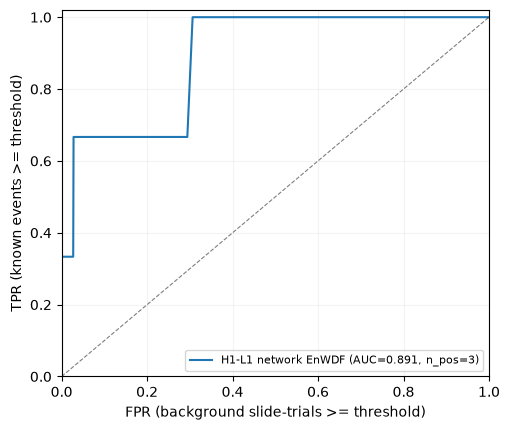

In [5]:
from wdf.analysis.roc import ROCCurve

distance = np.min(np.abs(RANKED.gps_candidate.to_numpy()[:, None] - SIGNAL_TIMES[None, :]), axis=1)
FOUND = RANKED[distance < 0.5]
print(f"{len(FOUND)} of {len(SIGNAL_TIMES)} injections recovered in coincidence")

roc = ROCCurve.from_results(FOUND, BACKGROUND, score_col="network_enwdf")
print(f"AUC = {roc.auc():.3f}")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
roc.plot(ax=ax, label="H1-L1 network EnWDF")
ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()

With three positives the curve is a staircase of three steps -- shown here so the
mechanics are visible, not because three events measure anything. A real
efficiency or ROC measurement needs a simulated set with hundreds of injections
spanning the signal-to-noise range where the threshold sits.

A caveat that applies to every number above, and to real analyses too: slides
within a single continuous segment are not independent the way day-scale slides
in a production search are, and one loud glitch can dominate many of them. Read
a false-alarm probability from this construction as "within this segment", not
as a calibrated rate per year.